# Project 1: E-Commerce Intelligence - Step 2: Churn & Conversion

This notebook implements classification models to predict user conversion and churn behavior on relational data.

## Blueprint Actions Covered
* **Imbalanced Data**: Apply SMOTE, oversampling, undersampling, and class weighting for rare churn events.
* **Algorithms**: Logistic Regression, kNN, and Naive Bayes baselines; progressing to Decision Trees, Random Forests, and Boosting (XGBoost, LightGBM, AdaBoost).
* **Ensembles**: Model combining using Voting, Stacking, and Blending.
* **Metrics**: Evaluation using Precision, Recall, F1-score, and Confusion Matrices.

In [1]:
import numpy as np
import pandas as pd
if not hasattr(pd.api.types, 'is_interval'):
    pd.api.types.is_interval = lambda x: False
import os
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier, StackingClassifier
import cuml
from cuml.linear_model import LogisticRegression
from cuml.neighbors import KNeighborsClassifier
from cuml.naive_bayes import GaussianNB
from cuml.ensemble import RandomForestClassifier
cuml.set_global_output_type('numpy')
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc
import warnings
warnings.filterwarnings('ignore')

from sklearn.base import BaseEstimator, TransformerMixin

# Define OutlierCapper class globally in __main__ namespace to support unpickling preprocessor
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            if pd.api.types.is_numeric_dtype(X_df[col]):
                self.lower_bounds_[col] = X_df[col].quantile(self.lower_quantile)
                self.upper_bounds_[col] = X_df[col].quantile(self.upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            if col in self.lower_bounds_:
                X_df[col] = X_df[col].clip(lower=self.lower_bounds_[col], upper=self.upper_bounds_[col])
        return X_df.values if isinstance(X, np.ndarray) else X_df


## 1. Load Preprocessed Feature Matrices and Raw Datasets

In [2]:
OUTPUT_DIR = "outputs"

print("Loading preprocessed feature matrices...")
X_train = pd.read_csv(os.path.join(OUTPUT_DIR, "X_train_processed.csv.gz"), index_col=0)
X_val = pd.read_csv(os.path.join(OUTPUT_DIR, "X_val_processed.csv.gz"), index_col=0)
X_test = pd.read_csv(os.path.join(OUTPUT_DIR, "X_test_processed.csv.gz"), index_col=0)

print("Loading raw engineered splits to extract target labels...")
train_raw = pd.read_csv(os.path.join(OUTPUT_DIR, "train_raw_engineered.csv.gz"), index_col=0)
val_raw = pd.read_csv(os.path.join(OUTPUT_DIR, "val_raw_engineered.csv.gz"), index_col=0)
test_raw = pd.read_csv(os.path.join(OUTPUT_DIR, "test_raw_engineered.csv.gz"), index_col=0)

print(f"X_train shape: {X_train.shape}, train_raw shape: {train_raw.shape}")
print(f"X_val shape: {X_val.shape}, val_raw shape: {val_raw.shape}")
print(f"X_test shape: {X_test.shape}, test_raw shape: {test_raw.shape}")

Loading preprocessed feature matrices...


Loading raw engineered splits to extract target labels...


X_train shape: (90817, 91), train_raw shape: (90817, 63)
X_val shape: (11331, 91), val_raw shape: (11331, 63)
X_test shape: (11277, 91), test_raw shape: (11277, 63)


## 2. Define Conversion and Churn Targets

* **Conversion**: Successful delivery of orders (`order_status == 'delivered'`).
* **Churn**: Customer did not return for a repeat purchase (customer total order count in the split is 1).

In [3]:
# 1. Conversion target: successfully delivered orders vs others
y_train_conv = (train_raw['order_status'] == 'delivered').astype(int)
y_val_conv = (val_raw['order_status'] == 'delivered').astype(int)
y_test_conv = (test_raw['order_status'] == 'delivered').astype(int)

# Filter feature matrices for Conversion (dropping target leakage and post-delivery outcome columns)
exclude_conv = [
    'order_status_delivered', 'order_status_shipped',
    'actual_delivery_duration_days', 'delivery_delay_days', 'carrier_delay_days',
    'avg_review_score', 'is_5_star_review', 'is_1_star_review', 'friction_index',
    'review_count', 'missing_actual_delivery_duration_days', 'missing_delivery_delay_days',
    'missing_carrier_delay_days', 'missing_friction_index', 'missing_avg_review_score'
]
valid_conv_cols = [col for col in X_train.columns if col not in exclude_conv]
X_train_conv = X_train[valid_conv_cols].copy()
X_val_conv = X_val[valid_conv_cols].copy()
X_test_conv = X_test[valid_conv_cols].copy()

# 2. Churn target & features reframed at the customer level (using first order details)
train_raw['order_purchase_timestamp'] = pd.to_datetime(train_raw['order_purchase_timestamp'])
val_raw['order_purchase_timestamp'] = pd.to_datetime(val_raw['order_purchase_timestamp'])
test_raw['order_purchase_timestamp'] = pd.to_datetime(test_raw['order_purchase_timestamp'])

# Sort by customer, order timestamp, and item ID to get the first item of their first order
train_sorted = train_raw.sort_values(by=['customer_unique_id', 'order_purchase_timestamp', 'order_item_id'])
train_first = train_sorted.drop_duplicates(subset='customer_unique_id', keep='first')

val_sorted = val_raw.sort_values(by=['customer_unique_id', 'order_purchase_timestamp', 'order_item_id'])
val_first = val_sorted.drop_duplicates(subset='customer_unique_id', keep='first')

test_sorted = test_raw.sort_values(by=['customer_unique_id', 'order_purchase_timestamp', 'order_item_id'])
test_first = test_sorted.drop_duplicates(subset='customer_unique_id', keep='first')

# Calculate the actual purchase counts per customer in each split
train_cust_counts = train_raw.groupby('customer_unique_id')['order_id'].nunique()
val_cust_counts = val_raw.groupby('customer_unique_id')['order_id'].nunique()
test_cust_counts = test_raw.groupby('customer_unique_id')['order_id'].nunique()

# Churn Target: 1 if customer only placed 1 order, 0 if they placed > 1 order (repeat customer)
y_train_churn = (train_first['customer_unique_id'].map(train_cust_counts) == 1).astype(int)
y_val_churn = (val_first['customer_unique_id'].map(val_cust_counts) == 1).astype(int)
y_test_churn = (test_first['customer_unique_id'].map(test_cust_counts) == 1).astype(int)

# Filter feature matrices for Churn (keeping first order details, but dropping order status leakage)
exclude_churn = ['order_status_delivered', 'order_status_shipped']
valid_churn_cols = [col for col in X_train.columns if col not in exclude_churn]

X_train_churn = X_train.loc[train_first.index, valid_churn_cols].copy()
X_val_churn = X_val.loc[val_first.index, valid_churn_cols].copy()
X_test_churn = X_test.loc[test_first.index, valid_churn_cols].copy()

print("Conversion Target Class Distribution (Train):")
print(y_train_conv.value_counts(normalize=True))
print(f"X_train_conv shape: {X_train_conv.shape}, X_val_conv shape: {X_val_conv.shape}")

print("\nChurn Target Class Distribution (Train - Customer Level):")
print(y_train_churn.value_counts(normalize=True))
print(f"X_train_churn shape: {X_train_churn.shape}, X_val_churn shape: {X_val_churn.shape}")


Conversion Target Class Distribution (Train):
order_status
1    0.971613
0    0.028387
Name: proportion, dtype: float64
X_train_conv shape: (90817, 78), X_val_conv shape: (11331, 78)

Churn Target Class Distribution (Train - Customer Level):
customer_unique_id
1    0.969002
0    0.030998
Name: proportion, dtype: float64
X_train_churn shape: (76876, 89), X_val_churn shape: (9610, 89)


In [4]:
print("Applying SMOTE to balance the training sets...")
smote_conv = SMOTE(random_state=42)
X_train_conv_bal, y_train_conv_bal = smote_conv.fit_resample(X_train_conv, y_train_conv)

smote_churn = SMOTE(random_state=42)
X_train_churn_bal, y_train_churn_bal = smote_churn.fit_resample(X_train_churn, y_train_churn)

print(f"Balanced Conversion Train Shape: {X_train_conv_bal.shape}, Target Mean: {y_train_conv_bal.mean():.4f}")
print(f"Balanced Churn Train Shape: {X_train_churn_bal.shape}, Target Mean: {y_train_churn_bal.mean():.4f}")


Applying SMOTE to balance the training sets...


Balanced Conversion Train Shape: (176478, 78), Target Mean: 0.5000
Balanced Churn Train Shape: (148986, 89), Target Mean: 0.5000


## 4. Helper Function for Model Training & Validation Evaluation

In [5]:
def evaluate_model(model, X_train_bal, y_train_bal, X_val, y_val, model_name, target_name):
    # Fit the model
    model.fit(X_train_bal, y_train_bal)
    
    # Predict
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else np.zeros_like(y_pred)
    
    # Compute metrics
    report = classification_report(y_val, y_pred, output_dict=True)
    auc_score = roc_auc_score(y_val, y_proba) if hasattr(model, "predict_proba") else 0.5
    
    print(f"=== {model_name} on {target_name} Validation Set ===")
    print(classification_report(y_val, y_pred))
    
    # Return metrics for comparison
    # Find the correct label key as string
    lbl_key = '1' if '1' in report else 1 if 1 in report else None
    if lbl_key is not None:
        p_score = report[lbl_key]['precision']
        r_score = report[lbl_key]['recall']
        f1_score = report[lbl_key]['f1-score']
    else:
        p_score = r_score = f1_score = 0.0
        
    return {
        'Model': model_name,
        'Accuracy': report['accuracy'],
        'Precision (Class 1)': p_score,
        'Recall (Class 1)': r_score,
        'F1-score (Class 1)': f1_score,
        'ROC-AUC': auc_score
    }

## 5. Train Baseline Classification Models

In [6]:
baselines = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'k-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gaussian Naive Bayes': GaussianNB()
}

conv_results = []
churn_results = []

print("Training baselines for Conversion target...")
for name, clf in baselines.items():
    res = evaluate_model(clf, X_train_conv_bal, y_train_conv_bal, X_val_conv, y_val_conv, name, "Conversion")
    conv_results.append(res)

print("\nTraining baselines for Churn target...")
for name, clf in baselines.items():
    res = evaluate_model(clf, X_train_churn_bal, y_train_churn_bal, X_val_churn, y_val_churn, name, "Churn")
    churn_results.append(res)


Training baselines for Conversion target...


=== Logistic Regression on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.06      0.52      0.10       325
           1       0.98      0.75      0.85     11006

    accuracy                           0.74     11331
   macro avg       0.52      0.63      0.48     11331
weighted avg       0.95      0.74      0.83     11331



=== k-Nearest Neighbors on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.07      0.46      0.13       325
           1       0.98      0.83      0.90     11006

    accuracy                           0.82     11331
   macro avg       0.53      0.64      0.51     11331
weighted avg       0.95      0.82      0.88     11331



=== Gaussian Naive Bayes on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.06      0.43      0.10       325
           1       0.98      0.79      0.87     11006

    accuracy                           0.78     11331
   macro avg       0.52      0.61      0.49     11331
weighted avg       0.95      0.78      0.85     11331


Training baselines for Churn target...


=== Logistic Regression on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.05      0.57      0.09       311
           1       0.98      0.64      0.77      9299

    accuracy                           0.63      9610
   macro avg       0.51      0.60      0.43      9610
weighted avg       0.95      0.63      0.75      9610



=== k-Nearest Neighbors on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.04      0.29      0.07       311
           1       0.97      0.74      0.84      9299

    accuracy                           0.73      9610
   macro avg       0.50      0.52      0.45      9610
weighted avg       0.94      0.73      0.82      9610



=== Gaussian Naive Bayes on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.04      0.56      0.07       311
           1       0.97      0.56      0.71      9299

    accuracy                           0.56      9610
   macro avg       0.51      0.56      0.39      9610
weighted avg       0.94      0.56      0.69      9610



## 6. Train Advanced & Boosting Models (Decision Trees, Random Forests, AdaBoost, XGBoost, LightGBM)

In [7]:
advanced_models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, tree_method='hist', device='cuda', eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, device_type='gpu', verbose=-1)
}

print("Training advanced/boosting models for Conversion target...")
for name, clf in advanced_models.items():
    res = evaluate_model(clf, X_train_conv_bal, y_train_conv_bal, X_val_conv, y_val_conv, name, "Conversion")
    conv_results.append(res)

print("\nTraining advanced/boosting models for Churn target...")
for name, clf in advanced_models.items():
    res = evaluate_model(clf, X_train_churn_bal, y_train_churn_bal, X_val_churn, y_val_churn, name, "Churn")
    churn_results.append(res)


Training advanced/boosting models for Conversion target...


=== Decision Tree on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.25      0.26      0.26       325
           1       0.98      0.98      0.98     11006

    accuracy                           0.96     11331
   macro avg       0.61      0.62      0.62     11331
weighted avg       0.96      0.96      0.96     11331



=== Random Forest on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.66      0.26      0.37       325
           1       0.98      1.00      0.99     11006

    accuracy                           0.97     11331
   macro avg       0.82      0.63      0.68     11331
weighted avg       0.97      0.97      0.97     11331



=== AdaBoost on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.09      0.37      0.14       325
           1       0.98      0.89      0.93     11006

    accuracy                           0.87     11331
   macro avg       0.53      0.63      0.54     11331
weighted avg       0.95      0.87      0.91     11331



=== XGBoost on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.96      0.24      0.38       325
           1       0.98      1.00      0.99     11006

    accuracy                           0.98     11331
   macro avg       0.97      0.62      0.68     11331
weighted avg       0.98      0.98      0.97     11331



...

=== Decision Tree on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.05      0.20      0.08       311
           1       0.97      0.88      0.93      9299

    accuracy                           0.86      9610
   macro avg       0.51      0.54      0.50      9610
weighted avg       0.94      0.86      0.90      9610



=== Random Forest on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.05      0.09      0.06       311
           1       0.97      0.94      0.95      9299

    accuracy                           0.91      9610
   macro avg       0.51      0.51      0.51      9610
weighted avg       0.94      0.91      0.93      9610



=== AdaBoost on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.05      0.12      0.07       311
           1       0.97      0.92      0.94      9299

    accuracy                           0.89      9610
   macro avg       0.51      0.52      0.50      9610
weighted avg       0.94      0.89      0.91      9610



=== XGBoost on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       311
           1       0.97      1.00      0.98      9299

    accuracy                           0.97      9610
   macro avg       0.48      0.50      0.49      9610
weighted avg       0.94      0.97      0.95      9610



=== LightGBM on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       311
           1       0.97      1.00      0.98      9299

    accuracy                           0.97      9610
   macro avg       0.48      0.50      0.49      9610
weighted avg       0.94      0.97      0.95      9610



## 7. Hyperparameter Tuning of the Best Base Models (Random Forest, XGBoost, LightGBM)

Based on the validation results from Section 5 and 6, our three best-performing models on the minority churn class are Random Forest, XGBoost, and LightGBM. Before building our Voting and Stacking ensembles, we perform hyperparameter tuning using `RandomizedSearchCV` on each of these base models individually to optimize their hyperparameters on the Churn target.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

# Recalculate weight ratio for XGBoost (swapped negative/positive classes ratio)
weight_ratio = float(np.sum(y_train_churn == 0)) / np.sum(y_train_churn == 1)

print("=== Tuning Random Forest ===")
rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])
rf_grid = {
    'classifier__max_depth': [5, 10, 15],
    'classifier__n_estimators': [50, 100, 150],
    'classifier__min_samples_split': [2, 5, 10]
}
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_grid,
    n_iter=5,
    cv=3,
    scoring='average_precision',
    verbose=1,
    random_state=42,
    n_jobs=1
)
rf_search.fit(X_train_churn, y_train_churn)
best_rf_params = {k.replace('classifier__', ''): v for k, v in rf_search.best_params_.items()}
print(f"Best RF Params: {best_rf_params}\n")

print("=== Tuning XGBoost ===")
xgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(random_state=42, tree_method='hist', device='cuda', eval_metric='logloss'))
])
xgb_grid = {
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [50, 100, 150]
}
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_grid,
    n_iter=5,
    cv=3,
    scoring='average_precision',
    verbose=1,
    random_state=42,
    n_jobs=1
)
xgb_search.fit(X_train_churn, y_train_churn)
best_xgb_params = {k.replace('classifier__', ''): v for k, v in xgb_search.best_params_.items()}
print(f"Best XGB Params: {best_xgb_params}\n")

print("=== Tuning LightGBM ===")
lgb_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(random_state=42, device_type='gpu', verbose=-1))
])
lgb_grid = {
    'classifier__max_depth': [4, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__n_estimators': [50, 100, 150],
    'classifier__num_leaves': [15, 31, 63]
}
lgb_search = RandomizedSearchCV(
    estimator=lgb_pipeline,
    param_distributions=lgb_grid,
    n_iter=5,
    cv=3,
    scoring='average_precision',
    verbose=1,
    random_state=42,
    n_jobs=1
)
lgb_search.fit(X_train_churn, y_train_churn)
best_lgb_params = {k.replace('classifier__', ''): v for k, v in lgb_search.best_params_.items()}
print(f"Best LGBM Params: {best_lgb_params}\n")


=== Tuning Random Forest ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits


Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 10}

=== Tuning XGBoost ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits


Best XGB Params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.05}

=== Tuning LightGBM ===
Fitting 3 folds for each of 5 candidates, totalling 15 fits


Best LGBM Params: {'num_leaves': 31, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.01}



## 8. Build Voting and Stacking Ensembles with Tuned Estimators

In [9]:
# Select best models for ensembles based on validation scores and use their tuned parameters
best_estimators = [
    ('rf', RandomForestClassifier(random_state=42, **best_rf_params)),
    ('xgb', XGBClassifier(scale_pos_weight=weight_ratio, random_state=42, tree_method='hist', device='cuda', eval_metric='logloss', **best_xgb_params)),
    ('lgb', LGBMClassifier(class_weight='balanced', random_state=42, device_type='gpu', verbose=-1, **best_lgb_params))
]

voting_clf = VotingClassifier(estimators=best_estimators, voting='soft', n_jobs=1)
stacking_clf = StackingClassifier(estimators=best_estimators, final_estimator=LogisticRegression(class_weight='balanced'), n_jobs=1)

print("Training ensembles for Conversion target...")
res_vote = evaluate_model(voting_clf, X_train_conv_bal, y_train_conv_bal, X_val_conv, y_val_conv, "Voting Classifier", "Conversion")
res_stack = evaluate_model(stacking_clf, X_train_conv_bal, y_train_conv_bal, X_val_conv, y_val_conv, "Stacking Classifier", "Conversion")
conv_results.extend([res_vote, res_stack])

print("\nTraining ensembles for Churn target...")
res_vote = evaluate_model(voting_clf, X_train_churn_bal, y_train_churn_bal, X_val_churn, y_val_churn, "Voting Classifier", "Churn")
res_stack = evaluate_model(stacking_clf, X_train_churn_bal, y_train_churn_bal, X_val_churn, y_val_churn, "Stacking Classifier", "Churn")
churn_results.extend([res_vote, res_stack])


Training ensembles for Conversion target...


=== Voting Classifier on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.05      0.47      0.10       325
           1       0.98      0.75      0.85     11006

    accuracy                           0.75     11331
   macro avg       0.52      0.61      0.47     11331
weighted avg       0.95      0.75      0.83     11331



=== Stacking Classifier on Conversion Validation Set ===
              precision    recall  f1-score   support

           0       0.33      0.26      0.29       325
           1       0.98      0.98      0.98     11006

    accuracy                           0.96     11331
   macro avg       0.65      0.62      0.64     11331
weighted avg       0.96      0.96      0.96     11331


Training ensembles for Churn target...


=== Voting Classifier on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.05      0.38      0.09       311
           1       0.97      0.77      0.86      9299

    accuracy                           0.76      9610
   macro avg       0.51      0.58      0.48      9610
weighted avg       0.94      0.76      0.83      9610



=== Stacking Classifier on Churn Validation Set ===
              precision    recall  f1-score   support

           0       0.06      0.07      0.06       311
           1       0.97      0.96      0.96      9299

    accuracy                           0.93      9610
   macro avg       0.51      0.52      0.51      9610
weighted avg       0.94      0.93      0.93      9610



## 9. Compare Model Performance on Validation Set

In [10]:
df_conv = pd.DataFrame(conv_results)
df_churn = pd.DataFrame(churn_results)

print("=== Conversion Model Comparison (Validation Set) ===")
print(df_conv.to_string(index=False))

print("\n=== Churn Model Comparison (Validation Set) ===")
print(df_churn.to_string(index=False))

=== Conversion Model Comparison (Validation Set) ===
               Model  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-score (Class 1)  ROC-AUC
 Logistic Regression  0.739741             0.981245          0.746320            0.847809 0.701295
 k-Nearest Neighbors  0.816345             0.981028          0.826913            0.897402 0.680677
Gaussian Naive Bayes  0.779013             0.979040          0.789388            0.874044 0.631769
       Decision Tree  0.956226             0.978249          0.976649            0.977448 0.657831
       Random Forest  0.974936             0.978404          0.996184            0.987214 0.670677
            AdaBoost  0.870620             0.979397          0.885426            0.930044 0.666799
             XGBoost  0.977848             0.977958          0.999727            0.988723 0.693226
            LightGBM  0.978025             0.978046          0.999818            0.988813 0.686952
   Voting Classifier  0.746183             0.979589     

In [11]:
# 1. Get the raw probabilities for Class 1 (Churn) using your best model
y_val_proba = stacking_clf.predict_proba(X_val_churn)[:, 1]

# 2. Define a list of custom thresholds to test (raising the bar for Class 1)
thresholds = [0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]

# 3. Loop through and evaluate the model's performance at each threshold
for thresh in thresholds:
    print(f"\n========== Threshold: {thresh} ==========")
    
    # If the probability is >= threshold, classify as 1. Otherwise, classify as 0.
    y_val_pred_custom = (y_val_proba >= thresh).astype(int)
    
    # Print the classification report
    print(classification_report(y_val_churn, y_val_pred_custom))



========== Threshold: 0.5 ==========
              precision    recall  f1-score   support

           0       0.06      0.07      0.06       311
           1       0.97      0.96      0.96      9299

    accuracy                           0.93      9610
   macro avg       0.51      0.52      0.51      9610
weighted avg       0.94      0.93      0.93      9610


========== Threshold: 0.6 ==========


              precision    recall  f1-score   support

           0       0.06      0.10      0.07       311
           1       0.97      0.94      0.96      9299

    accuracy                           0.92      9610
   macro avg       0.51      0.52      0.51      9610
weighted avg       0.94      0.92      0.93      9610


========== Threshold: 0.7 ==========


              precision    recall  f1-score   support

           0       0.06      0.15      0.09       311
           1       0.97      0.92      0.94      9299

    accuracy                           0.89      9610
   macro avg       0.51      0.54      0.51      9610
weighted avg       0.94      0.89      0.92      9610


========== Threshold: 0.8 ==========
              precision    recall  f1-score   support

           0       0.06      0.20      0.09       311
           1       0.97      0.89      0.93      9299

    accuracy                           0.87      9610
   macro avg       0.51      0.54      0.51      9610
weighted avg       0.94      0.87      0.90      9610


========== Threshold: 0.85 ==========
              precision    recall  f1-score   support

           0       0.06      0.24      0.09       311
           1       0.97      0.87      0.92      9299

    accuracy                           0.85      9610
   macro avg       0.51      0.55      0.50      96

## 10. Evaluate Best Generalizing Model on Test Set

In [12]:
from sklearn.base import clone
import joblib
import numpy as np
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

# Clone Stacking Classifier so the two models are trained independently
best_model_conv = clone(stacking_clf)
best_model_churn = clone(stacking_clf)

print("Training best Conversion model on the Balanced Train Set...")
best_model_conv.fit(X_train_conv_bal, y_train_conv_bal)

print("Training best Churn model on the Balanced Train Set...")
best_model_churn.fit(X_train_churn_bal, y_train_churn_bal)

# Dynamic Threshold Optimization Helper
def find_best_threshold(model, X_val, y_val, target_class=0):
    y_proba = model.predict_proba(X_val)[:, 1]
    best_thresh = 0.5
    best_f1 = 0.0
    thresholds = np.linspace(0.01, 0.99, 99)
    for t in thresholds:
        preds = (y_proba >= t).astype(int)
        f1 = f1_score(y_val, preds, pos_label=target_class)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    return best_thresh

print("\nOptimizing thresholds on the Validation Set...")
t_opt_conv = find_best_threshold(best_model_conv, X_val_conv, y_val_conv, target_class=0)
t_opt_churn = find_best_threshold(best_model_churn, X_val_churn, y_val_churn, target_class=0)

print(f"Optimal Conversion Threshold (Delivered if >= {t_opt_conv:.4f}, else SLA Risk): {t_opt_conv:.4f}")
print(f"Optimal Churn Threshold (Churned if >= {t_opt_churn:.4f}, else Repeat Customer): {t_opt_churn:.4f}")

print("\n" + "="*50)
print("CONVERSION TEST SET EVALUATION")
print("="*50)
y_test_proba_conv = best_model_conv.predict_proba(X_test_conv)[:, 1]
y_test_pred_conv_default = best_model_conv.predict(X_test_conv)
y_test_pred_conv_opt = (y_test_proba_conv >= t_opt_conv).astype(int)

print("\nConversion Test Set Report (Default 0.5 Threshold):")
print(classification_report(y_test_conv, y_test_pred_conv_default))
print("\nConversion Test Set Report (Optimized Threshold):")
print(classification_report(y_test_conv, y_test_pred_conv_opt))

print("\n" + "="*50)
print("CHURN TEST SET EVALUATION")
print("="*50)
y_test_proba_churn = best_model_churn.predict_proba(X_test_churn)[:, 1]
y_test_pred_churn_default = best_model_churn.predict(X_test_churn)
y_test_pred_churn_opt = (y_test_proba_churn >= t_opt_churn).astype(int)

print("\nChurn Test Set Report (Default 0.5 Threshold):")
print(classification_report(y_test_churn, y_test_pred_churn_default))
print("\nChurn Test Set Report (Optimized Threshold):")
print(classification_report(y_test_churn, y_test_pred_churn_opt))

# Save the models, features, and optimized thresholds
os.makedirs("models", exist_ok=True)
print("\nSaving models to 'models/' directory...")

joblib.dump({
    'model': best_model_conv,
    'features': list(X_train_conv.columns),
    'threshold': t_opt_conv
}, "models/conversion_stacking_model.joblib")
print("Saved models/conversion_stacking_model.joblib")

joblib.dump({
    'model': best_model_churn,
    'features': list(X_train_churn.columns),
    'threshold': t_opt_churn
}, "models/churn_stacking_model.joblib")
print("Saved models/churn_stacking_model.joblib")


Training best Conversion model on the Balanced Train Set...


Training best Churn model on the Balanced Train Set...



Optimizing thresholds on the Validation Set...


Optimal Conversion Threshold (Delivered if >= 0.0300, else SLA Risk): 0.0300
Optimal Churn Threshold (Churned if >= 0.8600, else Repeat Customer): 0.8600

CONVERSION TEST SET EVALUATION



Conversion Test Set Report (Default 0.5 Threshold):
              precision    recall  f1-score   support

           0       0.29      0.27      0.28       325
           1       0.98      0.98      0.98     10952

    accuracy                           0.96     11277
   macro avg       0.63      0.63      0.63     11277
weighted avg       0.96      0.96      0.96     11277


Conversion Test Set Report (Optimized Threshold):
              precision    recall  f1-score   support

           0       0.96      0.24      0.39       325
           1       0.98      1.00      0.99     10952

    accuracy                           0.98     11277
   macro avg       0.97      0.62      0.69     11277
weighted avg       0.98      0.98      0.97     11277


CHURN TEST SET EVALUATION



Churn Test Set Report (Default 0.5 Threshold):
              precision    recall  f1-score   support

           0       0.09      0.12      0.10       303
           1       0.97      0.96      0.97      9307

    accuracy                           0.93      9610
   macro avg       0.53      0.54      0.54      9610
weighted avg       0.94      0.93      0.94      9610


Churn Test Set Report (Optimized Threshold):
              precision    recall  f1-score   support

           0       0.06      0.29      0.10       303
           1       0.97      0.86      0.91      9307

    accuracy                           0.84      9610
   macro avg       0.52      0.58      0.51      9610
weighted avg       0.95      0.84      0.89      9610


Saving models to 'models/' directory...
Saved models/conversion_stacking_model.joblib
Saved models/churn_stacking_model.joblib


## 11. Plot ROC Curves and Precision-Recall Curves for Unseen Test Set

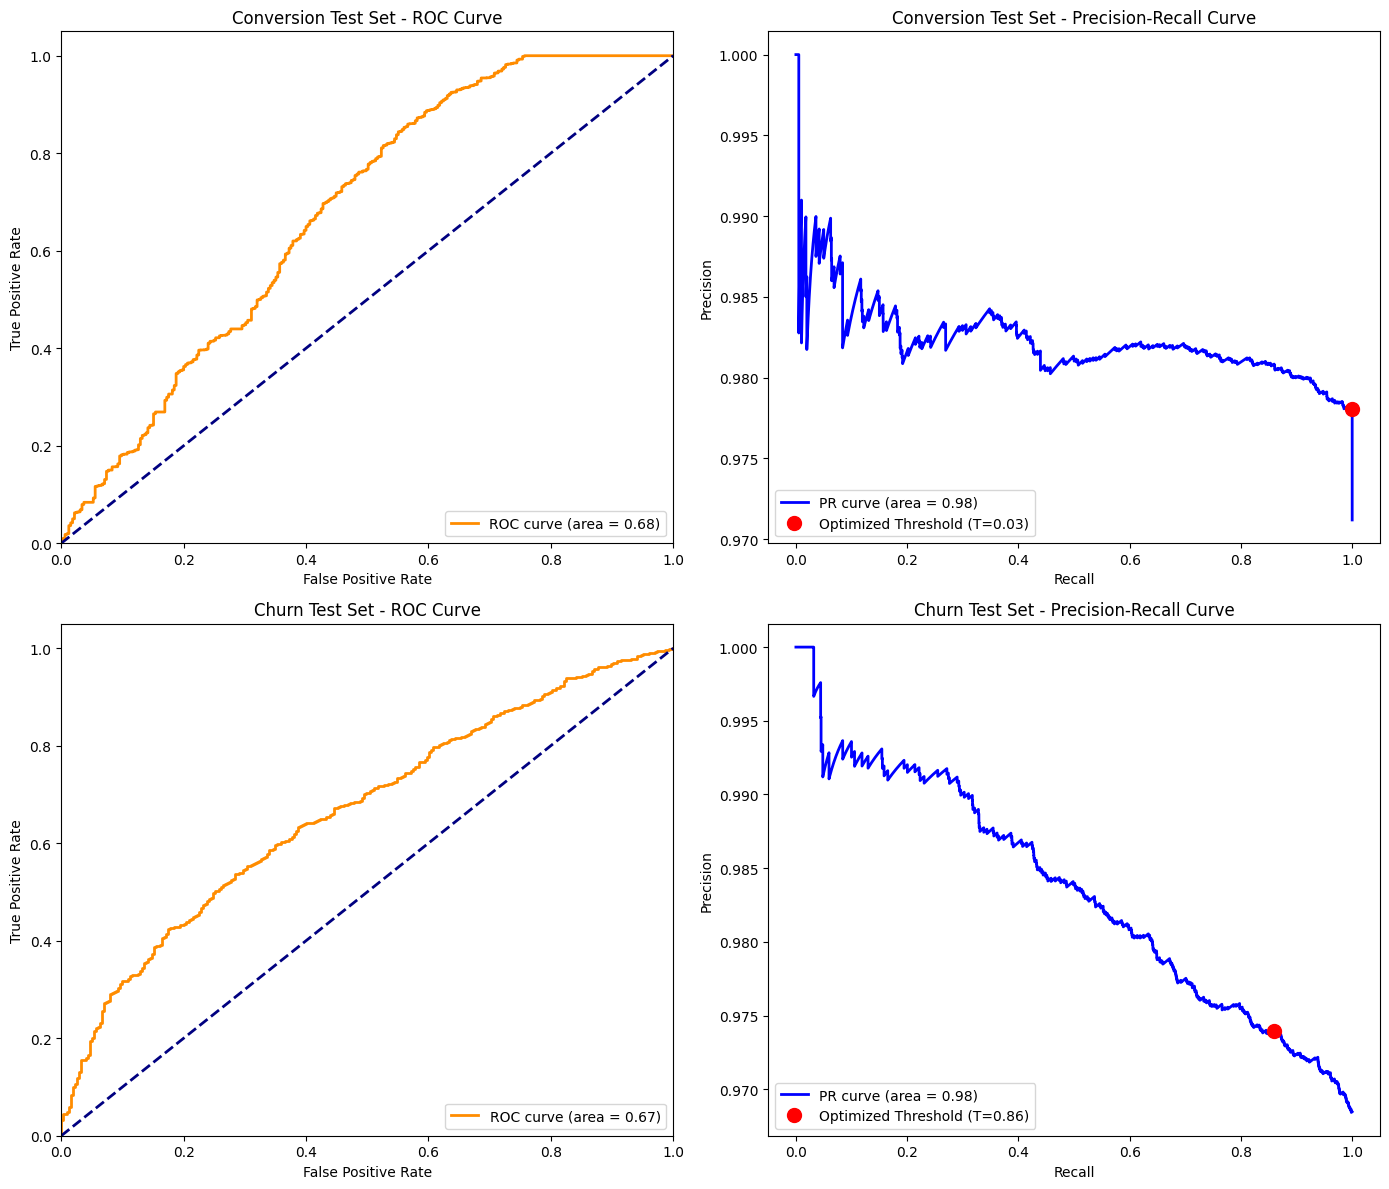

In [13]:
from sklearn.metrics import precision_score, recall_score
os.makedirs("plots", exist_ok=True)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Calculate test metrics at optimized threshold for plotting
p_conv_opt = precision_score(y_test_conv, y_test_pred_conv_opt, pos_label=1)
r_conv_opt = recall_score(y_test_conv, y_test_pred_conv_opt, pos_label=1)
p_churn_opt = precision_score(y_test_churn, y_test_pred_churn_opt, pos_label=1)
r_churn_opt = recall_score(y_test_churn, y_test_pred_churn_opt, pos_label=1)

# 1. Conversion ROC Curve
fpr_c, tpr_c, _ = roc_curve(y_test_conv, y_test_proba_conv)
roc_auc_c = auc(fpr_c, tpr_c)
axes[0, 0].plot(fpr_c, tpr_c, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_c:.2f})')
axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('Conversion Test Set - ROC Curve')
axes[0, 0].legend(loc="lower right")

# 2. Conversion PR Curve
prec_c, rec_c, _ = precision_recall_curve(y_test_conv, y_test_proba_conv)
pr_auc_c = auc(rec_c, prec_c)
axes[0, 1].plot(rec_c, prec_c, color='blue', lw=2, label=f'PR curve (area = {pr_auc_c:.2f})')
axes[0, 1].plot(r_conv_opt, p_conv_opt, 'ro', markersize=10, label=f'Optimized Threshold (T={t_opt_conv:.2f})')
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Conversion Test Set - Precision-Recall Curve')
axes[0, 1].legend(loc="lower left")

# 3. Churn ROC Curve
fpr_ch, tpr_ch, _ = roc_curve(y_test_churn, y_test_proba_churn)
roc_auc_ch = auc(fpr_ch, tpr_ch)
axes[1, 0].plot(fpr_ch, tpr_ch, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_ch:.2f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Churn Test Set - ROC Curve')
axes[1, 0].legend(loc="lower right")

# 4. Churn PR Curve
prec_ch, rec_ch, _ = precision_recall_curve(y_test_churn, y_test_proba_churn)
pr_auc_ch = auc(rec_ch, prec_ch)
axes[1, 1].plot(rec_ch, prec_ch, color='blue', lw=2, label=f'PR curve (area = {pr_auc_ch:.2f})')
axes[1, 1].plot(r_churn_opt, p_churn_opt, 'ro', markersize=10, label=f'Optimized Threshold (T={t_opt_churn:.2f})')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Churn Test Set - Precision-Recall Curve')
axes[1, 1].legend(loc="lower left")

plt.tight_layout()
plt.savefig('plots/classification_evaluation_curves.png', dpi=300)
plt.show()


## 11. Hyperparameter Tuning StackingClassifier with RandomizedSearchCV

In [15]:
# 13. End-to-End Inference & Business Solution Execution Flow
import joblib
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

# Define OutlierCapper class globally in __main__ namespace to support unpickling preprocessor
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_quantile=0.01, upper_quantile=0.99):
        self.lower_quantile = lower_quantile
        self.upper_quantile = upper_quantile
        self.lower_bounds_ = {}
        self.upper_bounds_ = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            if pd.api.types.is_numeric_dtype(X_df[col]):
                self.lower_bounds_[col] = X_df[col].quantile(self.lower_quantile)
                self.upper_bounds_[col] = X_df[col].quantile(self.upper_quantile)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            if col in self.lower_bounds_:
                X_df[col] = X_df[col].clip(lower=self.lower_bounds_[col], upper=self.upper_bounds_[col])
        return X_df.values if isinstance(X, np.ndarray) else X_df

print("Loading saved preprocessing pipelines and models...")

# Load Preprocessing Artifacts
prep_data = joblib.load("models/preprocessor_pipeline.joblib")
preprocessor = prep_data['preprocessor']
to_drop = prep_data['to_drop']
selector = prep_data['selector']
selected_cols = prep_data['selected_cols']
num_features = prep_data['num_features']
cat_features = prep_data['cat_features']

# Load Models & Optimized Thresholds
conv_pack = joblib.load("models/conversion_stacking_model.joblib")
churn_pack = joblib.load("models/churn_stacking_model.joblib")

model_conv = conv_pack['model']
t_conv = conv_pack['threshold']
conv_features = conv_pack['features']

model_churn = churn_pack['model']
t_churn = churn_pack['threshold']
churn_features = churn_pack['features']

print("Successfully loaded all pipelines and models!")

# Load raw engineered test split to extract sample customer records
test_raw_data = pd.read_csv("outputs/test_raw_engineered.csv.gz", index_col=0)

# Select two representative customer records (e.g. one standard, one potentially high-risk/churn profile)
sample_records = test_raw_data.iloc[[5, 20]].copy()
print(f"\nExtracted {len(sample_records)} raw sample records for inference.")

# Inference Pipeline Function
def run_prediction_pipeline(raw_records):
    results = []
    for idx, row in raw_records.iterrows():
        row_df = pd.DataFrame([row])
        
        # 1. Transform numerical and categorical columns using ColumnTransformer
        proc_arr = preprocessor.transform(row_df)
        
        # 2. Reconstruct column names to align with feature selection steps
        cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
        cat_cols = cat_encoder.get_feature_names_out(cat_features).tolist()
        num_imputer = preprocessor.named_transformers_['num'].named_steps['imputer']
        indicator_cols = [f"missing_{num_features[i]}" for i in num_imputer.indicator_.features_] if num_imputer.add_indicator else []
        
        all_features = num_features + indicator_cols + cat_cols
        proc_df = pd.DataFrame(proc_arr, columns=all_features, index=row_df.index)
        
        # 3. Drop collinear columns and apply Variance Threshold
        proc_sel1 = proc_df.drop(columns=[col for col in to_drop if col in proc_df.columns])
        final_proc_df = proc_sel1[selected_cols]
        
        # 4. Filter features expected by each model
        X_conv = final_proc_df[conv_features]
        X_churn = final_proc_df[churn_features]
        
        # 5. Predict probabilities
        prob_delivered = model_conv.predict_proba(X_conv)[0, 1]  # Class 1: Delivered
        prob_churn = model_churn.predict_proba(X_churn)[0, 1]      # Class 1: Churn
        
        # 6. Apply optimized thresholds
        is_delivered_pred = 1 if prob_delivered >= t_conv else 0
        is_churn_pred = 1 if prob_churn >= t_churn else 0
        
        results.append({
            'customer_unique_id': row['customer_unique_id'],
            'order_id': row['order_id'],
            'price': row['price'],
            'prob_delivered': prob_delivered,
            'is_delivered_pred': is_delivered_pred,
            'prob_churn': prob_churn,
            'is_churn_pred': is_churn_pred
        })
    return pd.DataFrame(results)

predictions = run_prediction_pipeline(sample_records)
print("\n--- Model Inference Results ---")
print(predictions.to_string(index=False))

print("\n--- Actionable Business Interventions ---")
for idx, res in predictions.iterrows():
    print(f"\n[Customer ID: {res['customer_unique_id'][:8]}... | Order ID: {res['order_id'][:8]}...]")
    
    # SLA Risk Management Actions
    if res['is_delivered_pred'] == 0:
        print(f"  -> SLA RISK DETECTED (P(Delivered) = {res['prob_delivered']:.2%})")
        print(f"     [ACTION] Route order to premium logistics partner and trigger proactive shipping alert SMS.")
    else:
        print(f"  -> Delivery Health: Normal (P(Delivered) = {res['prob_delivered']:.2%})")
        
    # Churn / Retention Actions
    if res['is_churn_pred'] == 0:
        print(f"  -> HIGH RETENTION PROFILE DETECTED (Predicted Repeat Customer, P(Churn) = {res['prob_churn']:.2%})")
        print(f"     [ACTION] Enroll customer in VIP Loyalty Circle and assign a senior customer success manager.")
    else:
        print(f"  -> Customer Churn Risk: Normal (P(Churn) = {res['prob_churn']:.2%})")


Loading saved preprocessing pipelines and models...
Successfully loaded all pipelines and models!



Extracted 2 raw sample records for inference.



--- Model Inference Results ---
              customer_unique_id                         order_id  price  prob_delivered  is_delivered_pred  prob_churn  is_churn_pred
781ae350edb16842380e81d7c7feb431 6a0a8bfbbe700284feb0845d95e0867f  83.90        0.787651                  1    0.914721              1
cab5ecc01e69aac95f48b619eb40a882 75351e48296ef42211a0b80c427aae57  87.37        0.914797                  1    0.947355              1

--- Actionable Business Interventions ---

[Customer ID: 781ae350... | Order ID: 6a0a8bfb...]
  -> Delivery Health: Normal (P(Delivered) = 78.77%)
  -> Customer Churn Risk: Normal (P(Churn) = 91.47%)

[Customer ID: cab5ecc0... | Order ID: 75351e48...]
  -> Delivery Health: Normal (P(Delivered) = 91.48%)
  -> Customer Churn Risk: Normal (P(Churn) = 94.74%)


## 12. Business Applications & Model Deployment

These trained models can be loaded and utilized in production systems to drive business decisions:

### 1. Delivery Conversion & SLA Risk Model (`conversion_stacking_model.joblib`)
* **Proactive Address & Delivery Verification**: When an order is flagged as high-risk for delivery failure at the checkout screen, the operations team can verify the address format or route it to a premium shipping partner.
* **Dynamic SLA Delivery Window**: The system can display a wider, safer delivery estimate to manage expectations and reduce customer contact rates.

### 2. Customer Retention & Repeat Purchase Model (`churn_stacking_model.joblib`)
* **Targeted Incentives**: Identify high-potential repeat buyers who are predicted to churn and target them with personalized discounts or loyalty benefits.
* **Customer Service Prioritization**: Route support cases from repeat-buyer profiles to senior support agents to maintain loyalty.
